In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, silhouette_score, adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import colorsys
import plotly.express as px
import umap
import webbrowser, os

In [127]:
df = pd.read_csv("csv/french_results.csv")

# Infos sur le dataset

In [128]:
print("Variables :\n")
print(list(df.columns))

print("\nHead :\n")
print(df.head())

print("\nInfo :\n")
print(df.info())

Variables :

['speaker_id', 'username', 'predicted_id', 'predicted_username', 'score', 'correct', 'gender', 'age', 'dialect', 'micro_make', 'micro_type', 'sampling_rate', 'emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9', 'emb_10', 'emb_11', 'emb_12', 'emb_13', 'emb_14', 'emb_15', 'emb_16', 'emb_17', 'emb_18', 'emb_19', 'emb_20', 'emb_21', 'emb_22', 'emb_23', 'emb_24', 'emb_25', 'emb_26', 'emb_27', 'emb_28', 'emb_29', 'emb_30', 'emb_31', 'emb_32', 'emb_33', 'emb_34', 'emb_35', 'emb_36', 'emb_37', 'emb_38', 'emb_39', 'emb_40', 'emb_41', 'emb_42', 'emb_43', 'emb_44', 'emb_45', 'emb_46', 'emb_47', 'emb_48', 'emb_49', 'emb_50', 'emb_51', 'emb_52', 'emb_53', 'emb_54', 'emb_55', 'emb_56', 'emb_57', 'emb_58', 'emb_59', 'emb_60', 'emb_61', 'emb_62', 'emb_63', 'emb_64', 'emb_65', 'emb_66', 'emb_67', 'emb_68', 'emb_69', 'emb_70', 'emb_71', 'emb_72', 'emb_73', 'emb_74', 'emb_75', 'emb_76', 'emb_77', 'emb_78', 'emb_79', 'emb_80', 'emb_81', 'emb_82', 'emb_83',

# Nettoyage des données

In [129]:
print("Valeurs manquantes")
missing = df.isnull().sum()
print(missing[missing > 0])

# Supprimer la colonne micro_make
if "micro_make" in df.columns:
    df = df.drop(columns=['micro_make'])

print(f"Shape après nettoyage : {df.shape}")


Valeurs manquantes
micro_make    23131
dtype: int64
Shape après nettoyage : (23131, 203)


In [130]:
pd.set_option('display.max_rows', None)
# Colonnes catégorielles
for col in ['gender', 'age', 'dialect', 'micro_type']:
    df[col] = df[col].astype('category')

# Identifiants
df['speaker_id'] = df['speaker_id'].astype('string')
df['predicted_id'] = df['predicted_id'].astype('string')

# Username
df['username'] = df['username'].astype('string')
df['predicted_username'] = df['predicted_username'].astype('string')
df['username'] = df['username'].str.lower()
df['predicted_username'] = df['predicted_username'].str.lower()

# Enlever les anonymous
df = df[df["username"] != "anonymous"]

print(df.dtypes)

speaker_id            string[python]
username              string[python]
predicted_id          string[python]
predicted_username    string[python]
score                        float64
correct                         bool
gender                      category
age                         category
dialect                     category
micro_type                  category
sampling_rate                  int64
emb_0                        float64
emb_1                        float64
emb_2                        float64
emb_3                        float64
emb_4                        float64
emb_5                        float64
emb_6                        float64
emb_7                        float64
emb_8                        float64
emb_9                        float64
emb_10                       float64
emb_11                       float64
emb_12                       float64
emb_13                       float64
emb_14                       float64
emb_15                       float64
e

Les personnes sur lesquelles le modèle s'est trompé malgré une forte confiance

In [131]:
faux_haute_confiance = df[
    (df['correct'] == False) & 
    (df['score'] > 0.8)
][['username', 'predicted_username', 'score']].sort_values('score', ascending=False)

print(faux_haute_confiance)

                           username            predicted_username     score
11071                      francois                       franois  0.841543
11458                       franois                      francois  0.834962
19324                  samuelbuffet                     anonymous  0.833584
6671   cedricvasseuraliasbeepmaster   cdricvasseuraliasbeepmaster  0.832308
11448                       franois                      francois  0.828423
4763                          arbae                     rabea2008  0.826586
6693   cedricvasseuraliasbeepmaster   cdricvasseuraliasbeepmaster  0.825507
20184                  samuelbuffet                     anonymous  0.825361
17142                         phils                        phil_s  0.821754
11055                      francois                       franois  0.820455
6703   cedricvasseuraliasbeepmaster  cedricvasseuraliasbeepmaster  0.817564
19321                  samuelbuffet                     anonymous  0.814417
4620        

Certaines personnes ont juste un pseudo légèrement différent donc ce sont les mêmes personnes en réalité. On nettoie ça

In [132]:
mapping = {
    'franois': 'francois',
    'cdricvasseuraliasbeepmaster': 'cedricvasseuraliasbeepmaster',
    'rabea2008': 'arbae',
    'phil_s': 'phils',
    'jpquantin': 'jpquanti',
    'lebourgphilippe4':'lebourgphilippe',
    'colinecarreremsncom':'colinecarrere',
    'thvenin':'thevenin',
    'thierryb':'thierry',
    'philippen':'philippe'
}

df['username'] = df['username'].replace(mapping)
df['predicted_username'] = df['predicted_username'].replace(mapping)

#on change cet anonymous en samuelbuffet après vérification dans le dataset, pareil pour garous/agoniste
df.loc[(df['username'] == 'anonymous') & (df['speaker_id'] == '20080912'), 'username'] = 'samuelbuffet'
df.loc[(df['predicted_username'] == 'anonymous') & (df['predicted_id'] == '20080912'), 'predicted_username'] = 'samuelbuffet'
df.loc[df['username'] == 'agoniste', 'username'] = 'garous'
df.loc[df['predicted_username'] == 'agoniste', 'predicted_username'] = 'garous'

df['correct'] = df['username'] == df['predicted_username']

In [133]:
faux_haute_confiance = df[
    (df['correct'] == False) & 
    (df['score'] > 0.6)
][['username', 'predicted_username','score']].sort_values('score', ascending=False)

print(faux_haute_confiance)
pd.reset_option('display.max_rows')

                 username            predicted_username     score
14168     libertairebesac                    jobesancon  0.780616
22867         wwwdarnoxfr                         lucas  0.766692
13327          jobesancon               libertairebesac  0.763136
6444                benot                           ben  0.762711
15061               lucas                   wwwdarnoxfr  0.761629
13332          jobesancon               libertairebesac  0.751173
7945                dth_0                         dth_1  0.749538
13282          jobesancon               libertairebesac  0.749384
6443                benot                           ben  0.749306
13115  jeanmarc_cortiella              gonzalezjeanmarc  0.742818
6448                benot                           ben  0.742159
6450                benot                           ben  0.739031
12134    gonzalezjeanmarc            jeanmarc_cortiella  0.737572
7944                dth_0                         dth_1  0.736375
7323      

# Analyse exploratoire

## Similarités cosinus intra et inter locuteurs

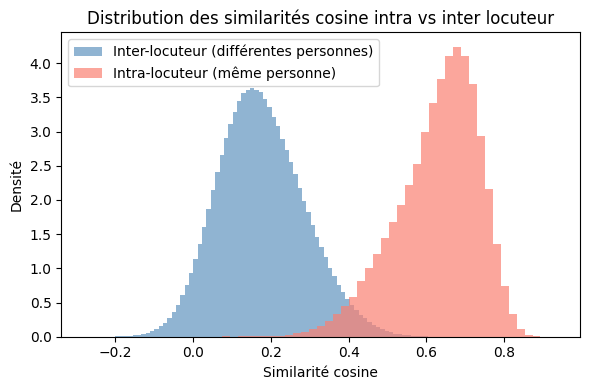

Similarité intra-locuteur moyenne : 0.6278
Similarité inter-locuteur moyenne : 0.1759
Séparation (intra - inter) : 0.4519


In [164]:
emb_cols = [c for c in df.columns if c.startswith("emb_")]
X = df[emb_cols].dropna().values
meta = df.loc[df[emb_cols].notna().all(axis=1)].reset_index(drop=True)

# Calcul sur un échantillon pour ne pas exploser la mémoire
sample_size = 3000
idx = np.random.choice(len(X), min(sample_size, len(X)), replace=False)
X_sample = X[idx]
labels_sample = meta['username'].iloc[idx].values

sim_matrix = cosine_similarity(X_sample)

intra, inter = [], []
for i in range(len(X_sample)):
    for j in range(i+1, len(X_sample)):
        if labels_sample[i] == labels_sample[j]:
            intra.append(sim_matrix[i, j])
        else:
            inter.append(sim_matrix[i, j])

plt.figure(figsize=(6, 4))
plt.hist(inter, bins=100, alpha=0.6, color='steelblue', label='Inter-locuteur (différentes personnes)', density=True)
plt.hist(intra, bins=50, alpha=0.7, color='salmon', label='Intra-locuteur (même personne)', density=True)
plt.xlabel('Similarité cosine')
plt.ylabel('Densité')
plt.title('Distribution des similarités cosine intra vs inter locuteur')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Similarité intra-locuteur moyenne : {np.mean(intra):.4f}")
print(f"Similarité inter-locuteur moyenne : {np.mean(inter):.4f}")
print(f"Séparation (intra - inter) : {np.mean(intra) - np.mean(inter):.4f}")

On remarque qu'il y a une plutôt bonne séparation entre la distribution des s

---------------------------------

# Performance globale

Accuracy globale

In [135]:
print(f"Accuracy globale : {df['correct'].mean():.2%}")
print(f"Total prédictions : {len(df)}")

Accuracy globale : 90.66%
Total prédictions : 19149


Distribution des scores

In [136]:
print(df.groupby('correct')['score'].describe())

           count      mean       std       min       25%       50%       75%  \
correct                                                                        
False     1788.0  0.535974  0.069870  0.273813  0.487221  0.526135  0.572626   
True     17361.0  0.663984  0.082252  0.349741  0.607969  0.669767  0.724337   

              max  
correct            
False    0.780616  
True     0.997951  


Seuil de décision optimal
Il faut maximiser le True Positive Rate et minimiser le False Positive Rate. On utilise la courbe ROC (Receiver Operating Characteristic). AUC = Area Under the Curve

In [137]:
fpr, tpr, thresholds = roc_curve(df['correct'], df['score'])
auc = roc_auc_score(df['correct'], df['score'])

# Seuil optimal
optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

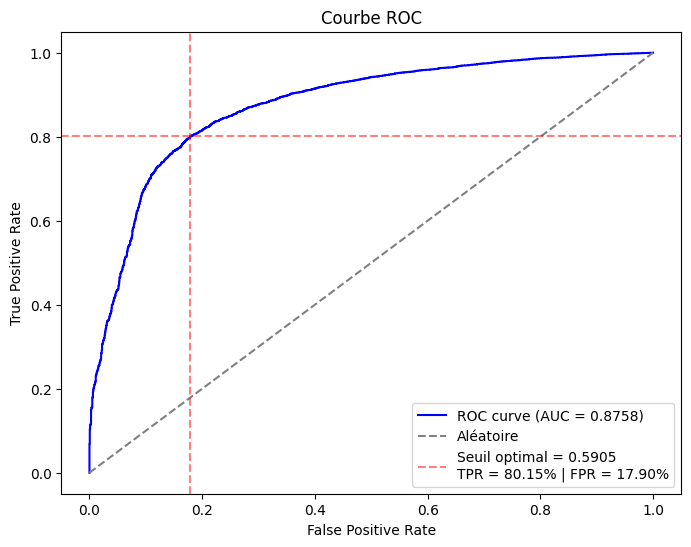

In [138]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aléatoire')
plt.axvline(x=fpr[optimal_idx], color='red', linestyle='--', alpha=0.5)
plt.axhline(y=tpr[optimal_idx], color='red', linestyle='--', alpha=0.5,
            label=f'Seuil optimal = {optimal_threshold:.4f}\nTPR = {tpr[optimal_idx]:.2%} | FPR = {fpr[optimal_idx]:.2%}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC')
plt.legend()
plt.show()

In [125]:
print(f"AUC : {auc:.4f}")
print(f"Seuil optimal : {optimal_threshold:.4f}")

AUC : 0.8758
Seuil optimal : 0.5905


Avec un seuil de 0.59, le modèle accepte correctement 80% des voix et en rejette 20% à tord. Il rejette 82.1% des voix correctement et accepte 17.9% par erreur.

# Biais et équité

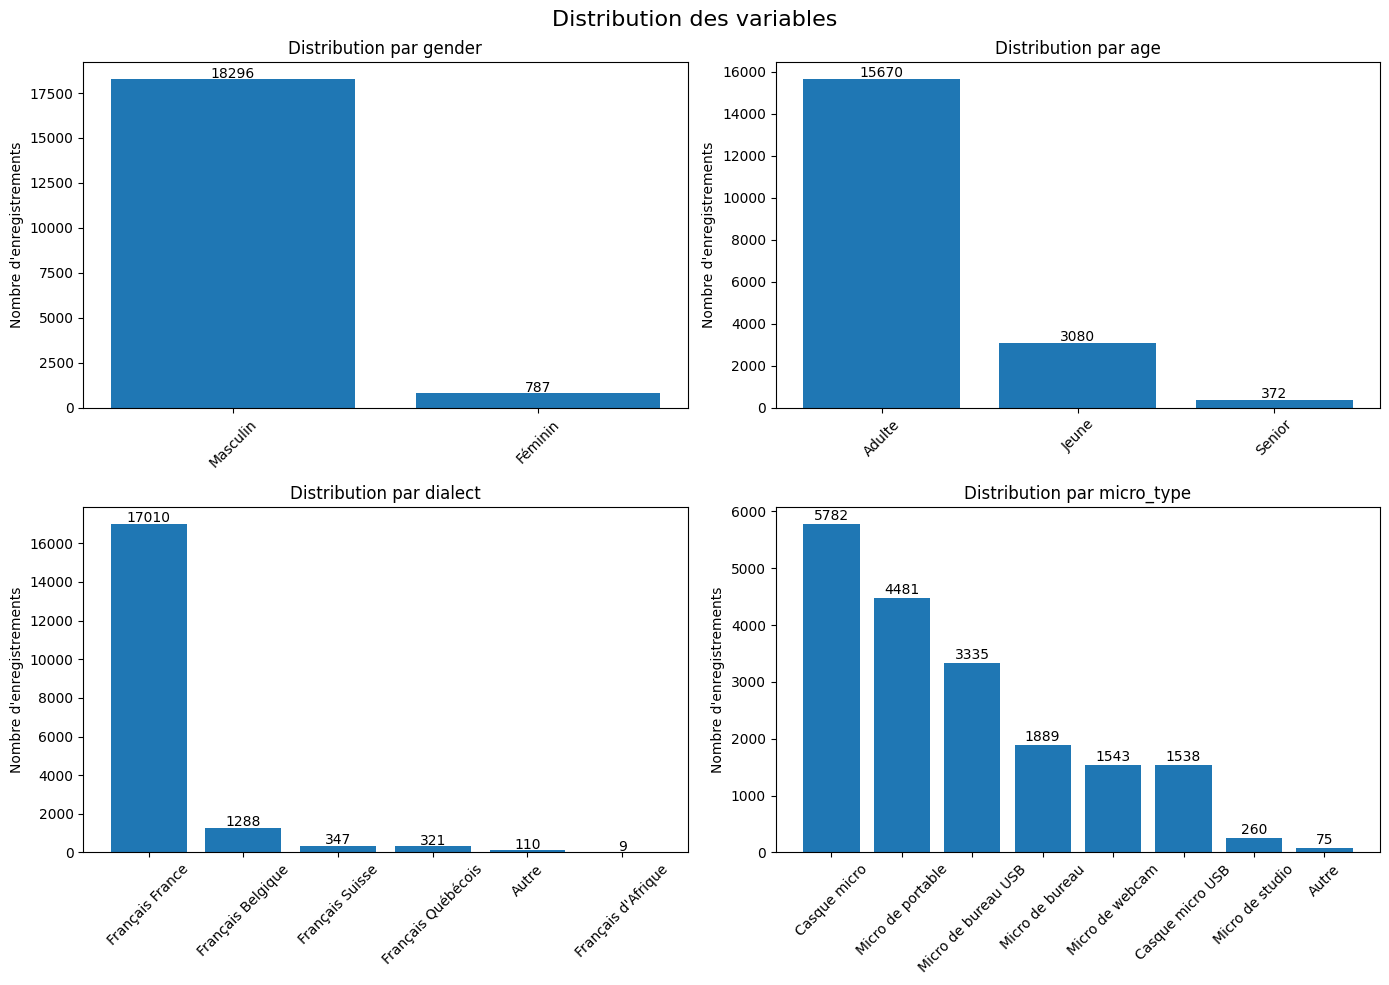

In [140]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribution des variables", fontsize=16)

for ax, col in zip(axes.flatten(), ['gender', 'age', 'dialect', 'micro_type']):
    data = df[col].value_counts()
    data = data[~data.index.isin(['Sélectionnez', 'inconnu'])]
    ax.bar(data.index.astype(str), data.values)
    ax.set_title(f"Distribution par {col}")
    ax.set_ylabel("Nombre d'enregistrements")
    ax.tick_params(axis='x', rotation=45)
    
    for i, val in enumerate(data.values):
        ax.text(i, val + 70, str(val), ha='center')

plt.tight_layout()
plt.show()

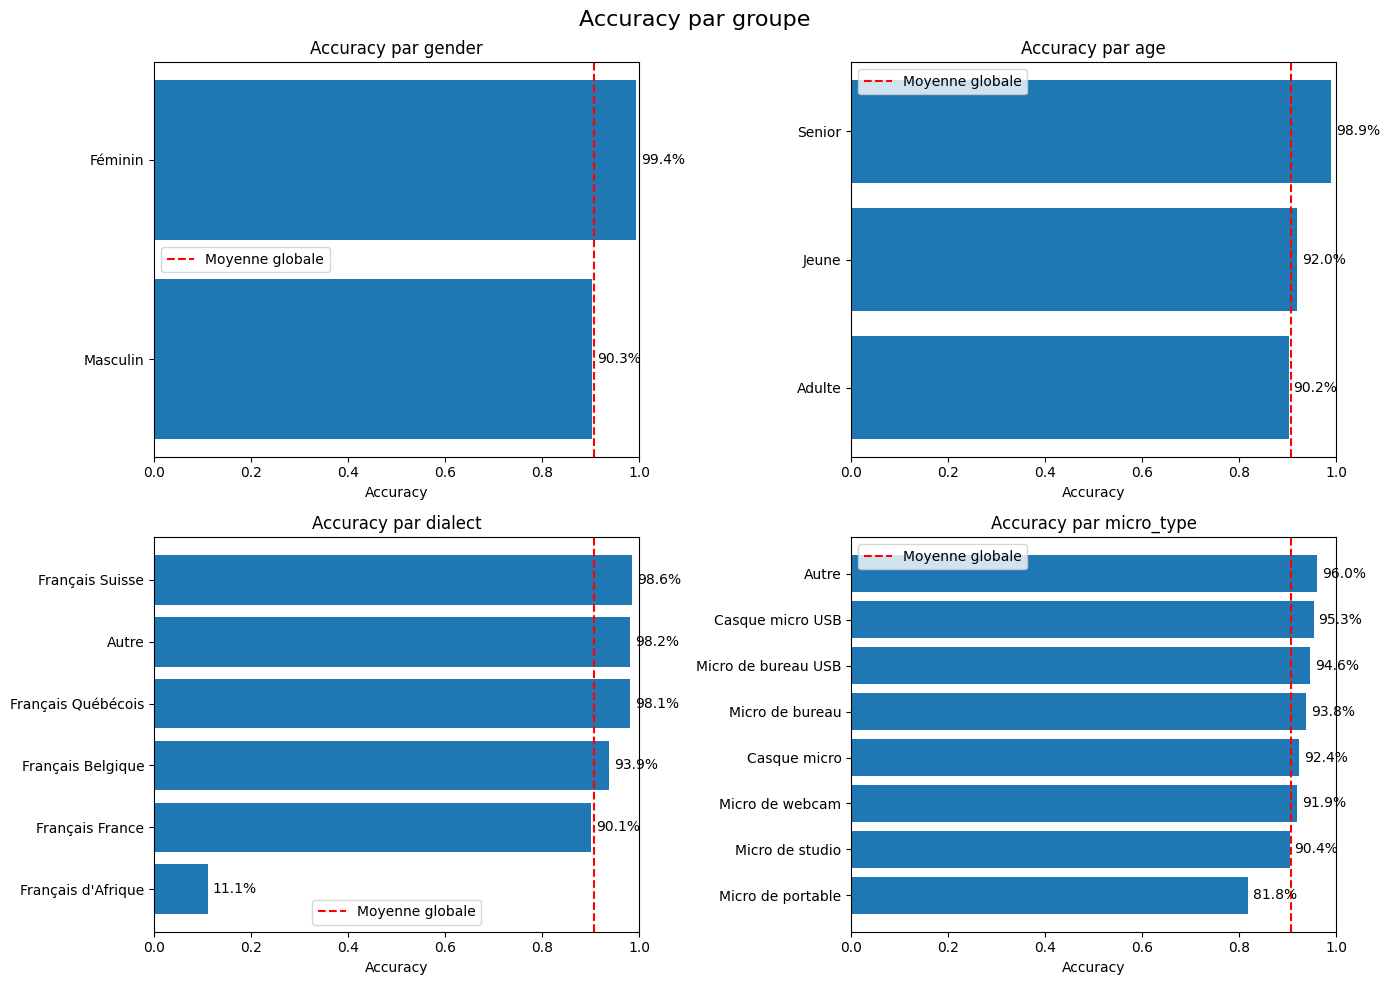

In [141]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Accuracy par groupe", fontsize=16)

for ax, col in zip(axes.flatten(), ['gender', 'age', 'dialect', 'micro_type']):
    temp = df.dropna(subset=[col]).copy()
    temp['correct'] = temp['correct'].astype(bool)
    data = temp.groupby(col, observed=True)['correct'].mean().sort_values()
    data = data[~data.index.isin(['Sélectionnez', 'inconnu'])]
    bars = ax.barh(data.index.astype(str), data.values.astype(float))
    ax.set_xlim(0, 1)
    ax.set_title(f"Accuracy par {col}")
    ax.set_xlabel("Accuracy")
    ax.axvline(x=df['correct'].astype(bool).mean(), color='red', linestyle='--', label='Moyenne globale')
    ax.legend()
    
    for bar, val in zip(bars, data.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center')

plt.tight_layout()
plt.show()

# Performance par speaker

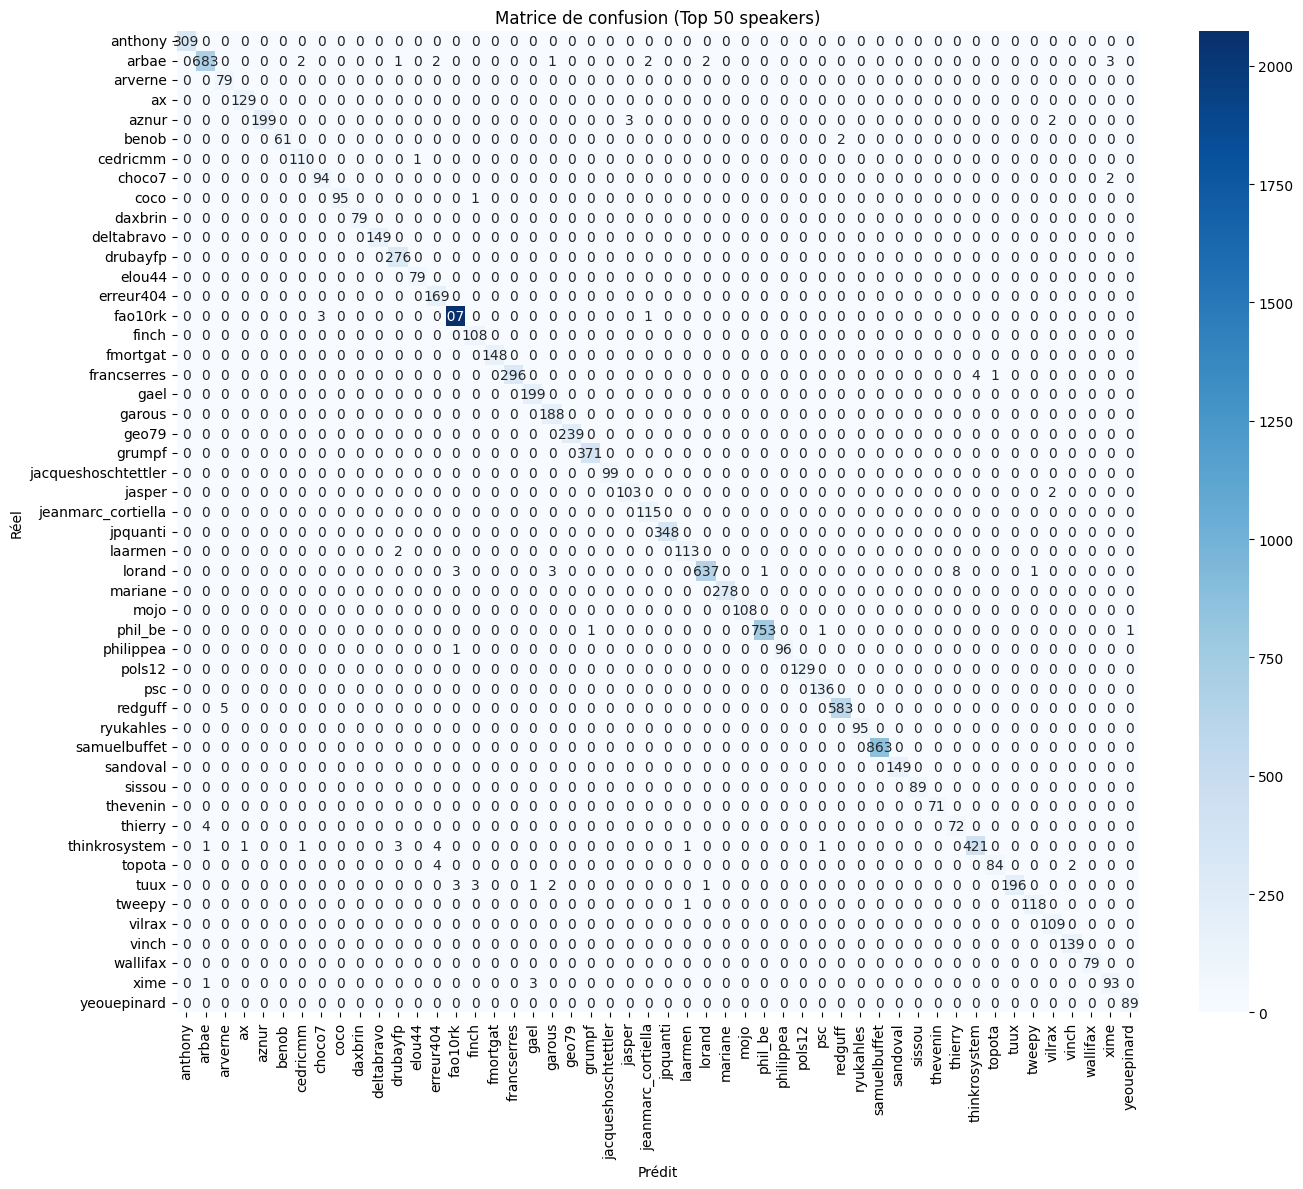

In [142]:
# Top 50 speakers les plus fréquents pour que la matrice soit lisible
top_speakers = df['username'].value_counts().head(50).index

temp = df[df['username'].isin(top_speakers) & df['predicted_username'].isin(top_speakers)]

confusion = pd.crosstab(temp['username'], temp['predicted_username'])

plt.figure(figsize=(14, 12))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion (Top 50 speakers)")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()

Les résultats sont presques toujours justes.

<Figure size 1400x800 with 0 Axes>

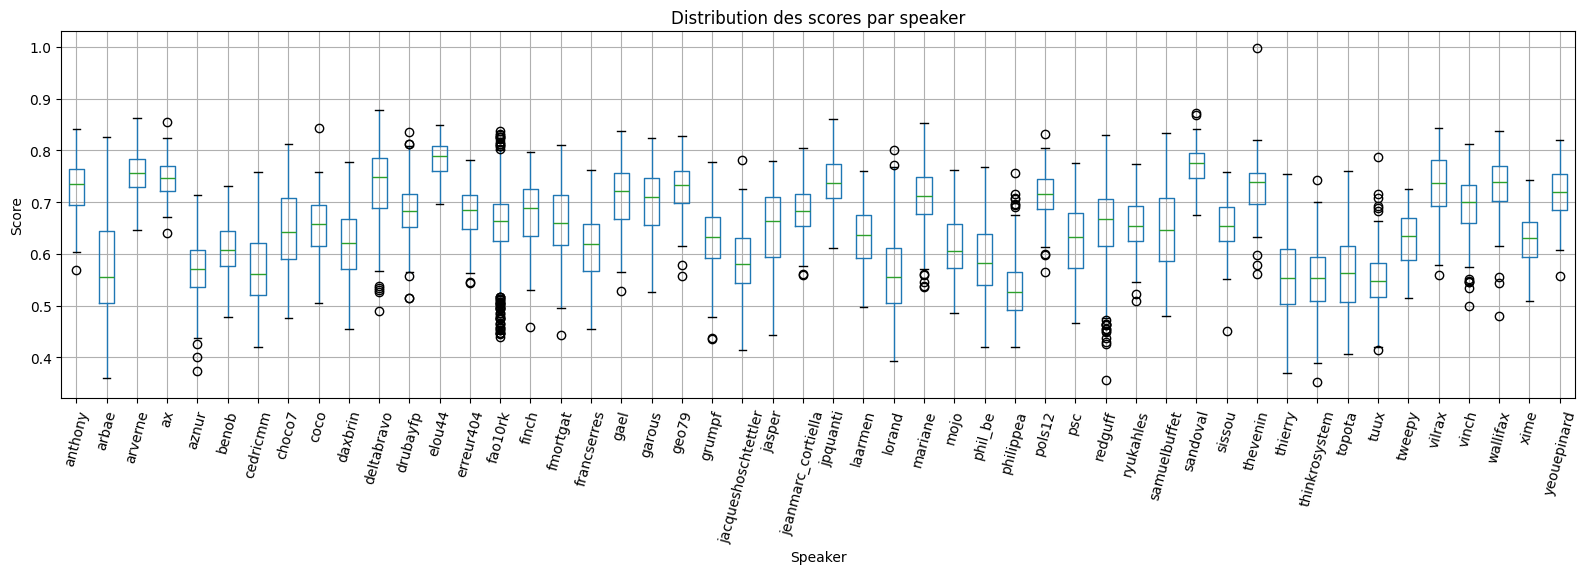

In [143]:
# Top 50 speakers les plus fréquents
top_speakers = df['username'].value_counts().head(50).index
temp = df[df['username'].isin(top_speakers)]

plt.figure(figsize=(14, 8))
temp.boxplot(column='score', by='username', figsize=(16, 6), rot=75)
plt.suptitle("")
plt.title("Distribution des scores par speaker")
plt.xlabel("Speaker")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

Fao10rk est un individu qui ressort parmi les autres, redguff aussi un peu, de par ses valeurs aberrantes. Regardons cela de plus près.

In [144]:
fao = df[df['username'] == 'fao10rk']

print(f"Nombre de tests : {len(fao)}")
print(f"Accuracy : {fao['correct'].mean():.2%}")
print(f"Score moyen : {fao['score'].mean():.4f}")
print(f"\nDistribution correct/incorrect :")
print(fao['correct'].value_counts())
print(f"\nQuand incorrect, prédit comme :")
print(fao[fao['correct'] == False]['predicted_username'].value_counts())
print(fao[fao['correct'] == False].groupby('predicted_username')['score'].describe())

Nombre de tests : 2156
Accuracy : 96.15%
Score moyen : 0.6593

Distribution correct/incorrect :
correct
True     2073
False      83
Name: count, dtype: Int64

Quand incorrect, prédit comme :
predicted_username
tof                   61
lcf                    6
choco7                 3
dominique              3
rowin                  3
tony                   2
jeanmarc_cortiella     1
dantheman              1
bob44                  1
belleil                1
philippe               1
Name: count, dtype: Int64
                    count      mean       std       min       25%       50%  \
predicted_username                                                            
belleil               1.0  0.556039       NaN  0.556039  0.556039  0.556039   
bob44                 1.0  0.493553       NaN  0.493553  0.493553  0.493553   
choco7                3.0  0.466709  0.034877  0.446549  0.446573  0.446597   
dantheman             1.0  0.578207       NaN  0.578207  0.578207  0.578207   
dominique      

Fao est surtout confondu avec tof. Regardons leurs caractéristiques

In [145]:
for user in ['fao10rk', 'tof']:
    print(f"\n--- {user} ---")
    print(df[df['username'] == user][['gender', 'age', 'dialect', 'micro_type']].drop_duplicates())


--- fao10rk ---
        gender     age          dialect           micro_type
8536  Masculin  Adulte  Français France  Micro de bureau USB

--- tof ---
         gender    age          dialect         micro_type
21685  Masculin  Jeune  Français France  Micro de portable


En écoutant les audios, les voix sont similaires mais ce n'est pas 100% sûr que ce soient les mêmes personnes car l'audio de tof est beaucoup plus étouffé que celui de fao. De plus, les enregistrements de tof datent de 2012, ceux de fao entre 2014 et 2016. 

Regardons maintenant redguff.

In [146]:
red = df[df['username'] == 'redguff']

print(f"Nombre de tests : {len(fao)}")
print(f"Accuracy : {fao['correct'].mean():.2%}")
print(f"Score moyen : {fao['score'].mean():.4f}")
print(f"\nDistribution correct/incorrect :")
print(fao['correct'].value_counts())
print(f"\nQuand incorrect, prédit comme :")
print(fao[fao['correct'] == False]['predicted_username'].value_counts())
print(fao[fao['correct'] == False].groupby('predicted_username')['score'].describe())

Nombre de tests : 2156
Accuracy : 96.15%
Score moyen : 0.6593

Distribution correct/incorrect :
correct
True     2073
False      83
Name: count, dtype: Int64

Quand incorrect, prédit comme :
predicted_username
tof                   61
lcf                    6
choco7                 3
dominique              3
rowin                  3
tony                   2
jeanmarc_cortiella     1
dantheman              1
bob44                  1
belleil                1
philippe               1
Name: count, dtype: Int64
                    count      mean       std       min       25%       50%  \
predicted_username                                                            
belleil               1.0  0.556039       NaN  0.556039  0.556039  0.556039   
bob44                 1.0  0.493553       NaN  0.493553  0.493553  0.493553   
choco7                3.0  0.466709  0.034877  0.446549  0.446573  0.446597   
dantheman             1.0  0.578207       NaN  0.578207  0.578207  0.578207   
dominique      

Pour les 2, malgré ces quelques valeurs aberrantes, ils ont une très bonne accuracy et score moyen. Le modèle fonctionne bien.

In [147]:
by_speaker = df.groupby('username').agg(
    accuracy=('correct', 'mean'),
    n_tests=('correct', 'count'),
    score_moyen=('score', 'mean')
).sort_values('accuracy')

print(by_speaker)

              accuracy  n_tests  score_moyen
username                                    
lorkscorguar       0.0       19     0.510318
lucas         0.101695       59     0.525711
dth_0         0.111111        9     0.663413
ramzi         0.230769       39     0.497126
ben           0.241379       29     0.578764
...                ...      ...          ...
jpetazzo           1.0        9     0.720645
jpquanti           1.0      348     0.739349
jr38francis        1.0       19     0.673677
jbl                1.0        9     0.710083
zg                 1.0        9     0.660055

[312 rows x 3 columns]


Speakers les mieux reconnus

In [149]:
print(by_speaker.tail(10))

             accuracy  n_tests  score_moyen
username                                   
jerome            1.0       28     0.715003
jim               1.0        9     0.702624
jnbianco          1.0       19     0.752999
jonathanmm        1.0        9     0.624692
jouflu            1.0       19     0.679473
jpetazzo          1.0        9     0.720645
jpquanti          1.0      348     0.739349
jr38francis       1.0       19     0.673677
jbl               1.0        9     0.710083
zg                1.0        9     0.660055


Speakers les moins bien reconnus

In [150]:
print(by_speaker.head(10))

              accuracy  n_tests  score_moyen
username                                    
lorkscorguar       0.0       19     0.510318
lucas         0.101695       59     0.525711
dth_0         0.111111        9     0.663413
ramzi         0.230769       39     0.497126
ben           0.241379       29     0.578764
wwwdarnoxfr   0.315789       19     0.700922
gsx           0.368421       19     0.525267
paco          0.384615       39     0.536229
benot         0.444444        9     0.717722
ckiw          0.473684       19     0.616573


Nombre de tests par speaker

In [151]:
print(by_speaker['n_tests'].sort_values(ascending=False))

username
fao10rk         2156
arbae           1158
samuelbuffet    1069
phil_be          819
lorand           719
                ... 
vince              9
toutjuste          9
nico               9
zg                 9
benbull            8
Name: n_tests, Length: 312, dtype: Int64


# Analyse des erreurs

Faux positifs à haute confiance

In [152]:
faux_haute_confiance = df[
    (df['correct'] == False) &
    (df['score'] > 0.6)
][['username', 'predicted_username', 'score']].sort_values('score', ascending=False)

print(faux_haute_confiance)

               username            predicted_username     score
14168   libertairebesac                    jobesancon  0.780616
22867       wwwdarnoxfr                         lucas  0.766692
13327        jobesancon               libertairebesac  0.763136
6444              benot                           ben  0.762711
15061             lucas                   wwwdarnoxfr  0.761629
...                 ...                           ...       ...
20187      samuelbuffet                          nico  0.601050
5445              arbae  cedricvasseuraliasbeepmaster  0.600540
12118  gonzalezjeanmarc            jeanmarc_cortiella  0.600353
6759             choco7                          olge  0.600233
4983              arbae                        trimss  0.600073

[285 rows x 3 columns]


Paires de speakers souvent confondus entre eux

In [153]:
paires = df[df['correct'] == False].groupby(
    ['username', 'predicted_username']
).size().reset_index(name='count').sort_values('count', ascending=False)

print(paires.head(20))

               username            predicted_username  count
11                arbae  cedricvasseuraliasbeepmaster    193
161  jeanmarc_cortiella              gonzalezjeanmarc     71
127             fao10rk                           tof     61
346        samuelbuffet                          nclm     46
345        samuelbuffet                      nanochan     40
46                arbae                          yawn     38
166          jobesancon               libertairebesac     33
342        samuelbuffet                        jerome     32
194              lorand                       d3m0t3p     31
350        samuelbuffet                         rowin     28
292           philippea                          nclm     26
411                tuux                      jfornech     24
9                 arbae                       candide     23
36                arbae                      seb02859     22
18                arbae                         frank     21
34                arbae 

Est-ce que le modèle confond toujours les mêmes personnes ?

In [154]:
confusions_par_speaker = df[df['correct'] == False].groupby('username').agg(
    nb_erreurs=('correct', 'count'),
    speakers_confondus=('predicted_username', 'nunique')
).sort_values('nb_erreurs', ascending=False)

print(confusions_par_speaker.head(20))

                    nb_erreurs  speakers_confondus
username                                          
arbae                      475                  43
samuelbuffet               206                  15
fao10rk                     83                  11
tuux                        83                  23
lorand                      82                  21
jeanmarc_cortiella          74                   3
thinkrosystem               70                  25
phil_be                     66                  13
philippea                   63                  15
lucas                       53                  14
jobesancon                  33                   1
ramzi                       30                  17
choco7                      25                   9
paco                        24                   6
francserres                 23                   6
ben                         22                   9
gonzalezjeanmarc            20                   1
lorkscorguar                19 

## Analyse des erreurs par groupe

In [155]:
# Est-ce que les erreurs se font entre mêmes genres, dialectes, âges ?
erreurs = df[df['correct'] == False].copy()

print("--- Même genre ? ---")
erreurs['meme_genre'] = erreurs['gender'] == erreurs['predicted_username'].map(df.groupby('username')['gender'].first())
print(erreurs['meme_genre'].value_counts(normalize=True))

print("\n--- Même âge ? ---")
erreurs['meme_age'] = erreurs['age'] == erreurs['predicted_username'].map(df.groupby('username')['age'].first())
print(erreurs['meme_age'].value_counts(normalize=True))

print("\n--- Même dialecte ? ---")
erreurs['meme_dialecte'] = erreurs['dialect'] == erreurs['predicted_username'].map(df.groupby('username')['dialect'].first())
print(erreurs['meme_dialecte'].value_counts(normalize=True))

--- Même genre ? ---
meme_genre
True     0.988814
False    0.011186
Name: proportion, dtype: float64

--- Même âge ? ---
meme_age
True     0.720358
False    0.279642
Name: proportion, dtype: float64

--- Même dialecte ? ---
meme_dialecte
True     0.871365
False    0.128635
Name: proportion, dtype: float64


Les erreurs sont surtout faites entre personnes similaires.

## Performance par locuteur

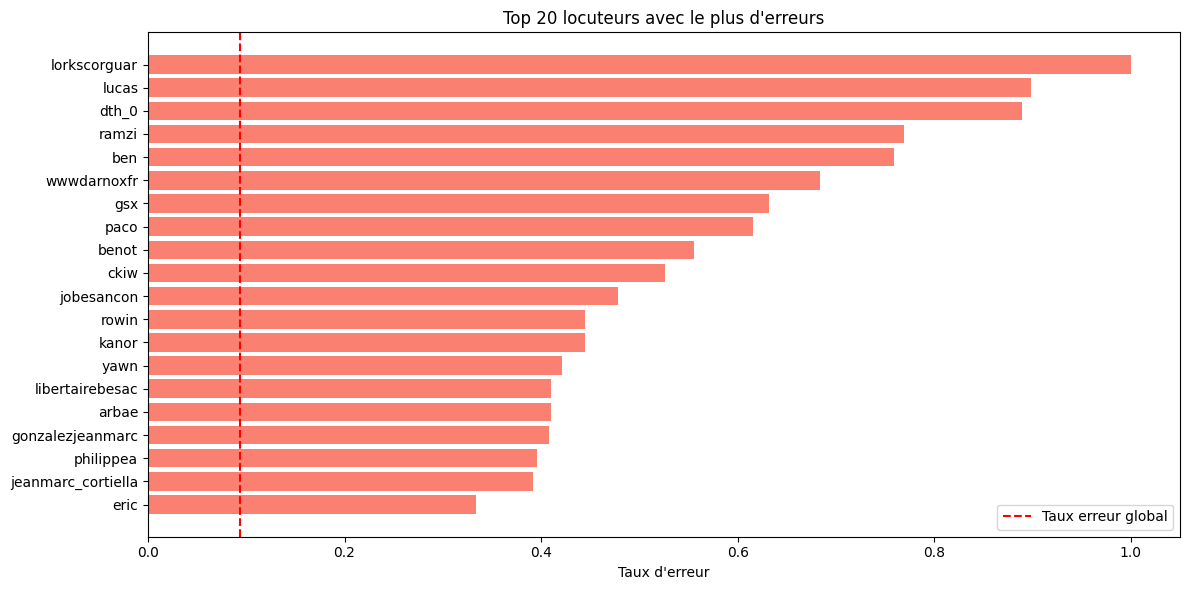

In [156]:
# Taux d'erreur par locuteur
perf_par_locuteur = df.groupby('username').agg(
    nb_predictions=('correct', 'count'),
    nb_erreurs=('correct', lambda x: (~x).sum()),
    taux_erreur=('correct', lambda x: (~x).mean())
).sort_values('taux_erreur', ascending=False).reset_index()

# Garder seulement ceux avec assez de prédictions (évite les locuteurs avec 1 seul audio)
perf_par_locuteur = perf_par_locuteur[perf_par_locuteur['nb_predictions'] >= 3]

top20_pires = perf_par_locuteur.head(20)

plt.figure(figsize=(12, 6))
bars = plt.barh(top20_pires['username'], top20_pires['taux_erreur'], color='salmon')
plt.axvline(x=df['correct'].eq(False).mean(), color='red', linestyle='--', label='Taux erreur global')
plt.xlabel('Taux d\'erreur')
plt.title('Top 20 locuteurs avec le plus d\'erreurs')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Distribution similarité cosine intra/inter locuteur

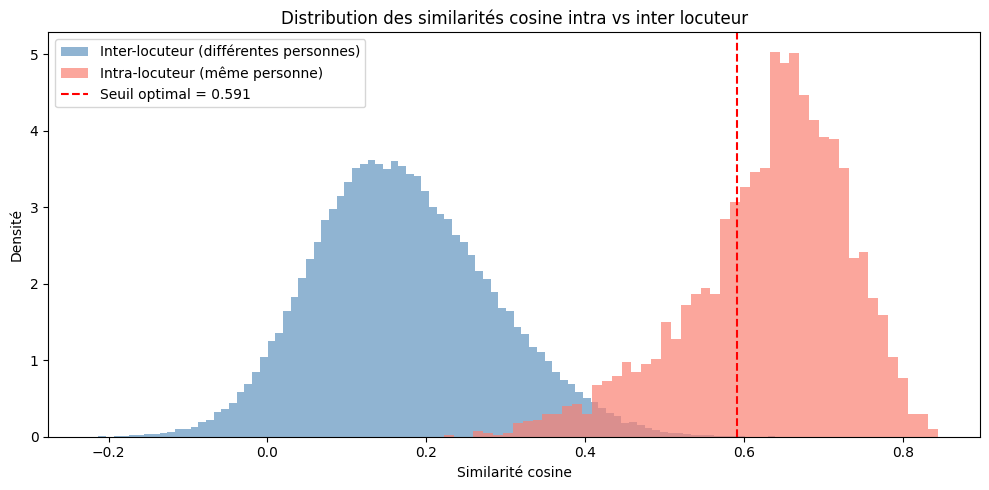

Similarité intra-locuteur moyenne : 0.6300
Similarité inter-locuteur moyenne : 0.1709
Séparation (intra - inter) : 0.4590


In [157]:
from sklearn.metrics.pairwise import cosine_similarity

emb_cols = [c for c in df.columns if c.startswith("emb_")]
X = df[emb_cols].dropna().values
meta = df.loc[df[emb_cols].notna().all(axis=1)].reset_index(drop=True)

# Calcul sur un échantillon pour ne pas exploser la mémoire
sample_size = 500
idx = np.random.choice(len(X), min(sample_size, len(X)), replace=False)
X_sample = X[idx]
labels_sample = meta['username'].iloc[idx].values

sim_matrix = cosine_similarity(X_sample)

intra, inter = [], []
for i in range(len(X_sample)):
    for j in range(i+1, len(X_sample)):
        if labels_sample[i] == labels_sample[j]:
            intra.append(sim_matrix[i, j])
        else:
            inter.append(sim_matrix[i, j])

plt.figure(figsize=(10, 5))
plt.hist(inter, bins=100, alpha=0.6, color='steelblue', label='Inter-locuteur (différentes personnes)', density=True)
plt.hist(intra, bins=50, alpha=0.7, color='salmon', label='Intra-locuteur (même personne)', density=True)
plt.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Seuil optimal = {optimal_threshold:.3f}')
plt.xlabel('Similarité cosine')
plt.ylabel('Densité')
plt.title('Distribution des similarités cosine intra vs inter locuteur')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Similarité intra-locuteur moyenne : {np.mean(intra):.4f}")
print(f"Similarité inter-locuteur moyenne : {np.mean(inter):.4f}")
print(f"Séparation (intra - inter) : {np.mean(intra) - np.mean(inter):.4f}")

L'analyse des vecteurs d'embedding révèle une très bonne séparation entre les locuteurs. La Figure X montre que les similarités cosine intra-locuteur (deux audios de la même personne) sont concentrées autour de 0.95-1.0, tandis que les similarités inter-locuteur (personnes différentes) sont distribuées entre 0.0 et 0.3. Le chevauchement minimal entre les deux distributions indique que les embeddings ECAPA-TDNN encodent de façon robuste et discriminante l'identité du locuteur. Le seuil optimal identifié à 0.591 par la courbe ROC se positionne précisément dans le creux entre les deux distributions, permettant une classification fiable.
Cette forte séparation suggère que les erreurs observées dans le benchmark ne résultent pas d'une ambiguïté intrinsèque du modèle, mais plutôt de facteurs externes : qualité audio variable, locuteurs aux voix phonétiquement similaires, ou nombre insuffisant d'enregistrements d'entraînement pour certains locuteurs. Les cas de confusion à haute confiance (score > 0.8 mais prédiction incorrecte) correspondent à ces situations limites, où deux voix distinctes produisent des embeddings fortement similaires.

## Matrice de confusion réduite — top 30 locuteurs les plus confondus

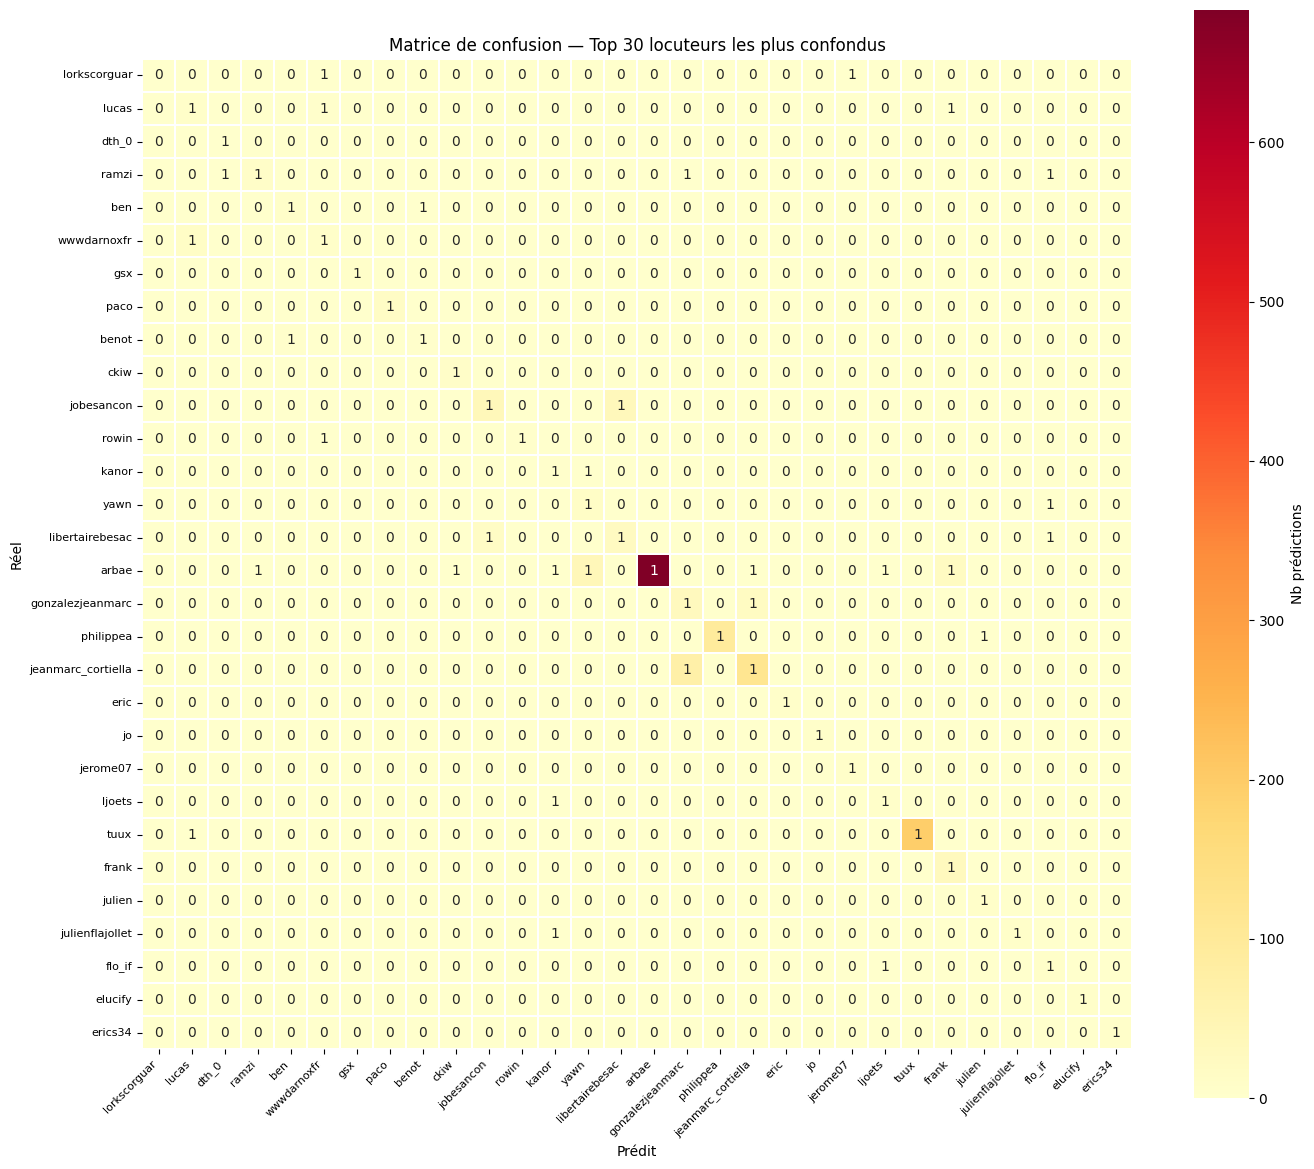

In [158]:
# Identifier les 30 locuteurs avec le plus d'erreurs
top_confus = perf_par_locuteur.head(30)['username'].tolist()

df_reduit = df[df['username'].isin(top_confus)]

# Construire la matrice de confusion
confusion = df_reduit.groupby(['username', 'predicted_username']).size().unstack(fill_value=0)
confusion = confusion.reindex(index=top_confus, columns=top_confus, fill_value=0)

plt.figure(figsize=(14, 12))
sns.heatmap(
    confusion,
    cmap='YlOrRd',
    linewidths=0.3,
    square=True,
    cbar_kws={'label': 'Nb prédictions'},
    annot=confusion.values > 0,  # n'annote que les cases non nulles
    fmt='d'
)
plt.title('Matrice de confusion — Top 30 locuteurs les plus confondus')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [159]:
# Trouver la paire de confusion la plus fréquente impliquant arbae
arbae_confusions = df[
    (df['username'] == 'arbae') & 
    (df['correct'] == False)
].groupby('predicted_username').size().sort_values(ascending=False)

print("Arbae est confondu avec :")
print(arbae_confusions.head())

Arbae est confondu avec :
predicted_username
cedricvasseuraliasbeepmaster    193
yawn                             38
candide                          23
seb02859                         22
frank                            21
dtype: int64


# Seuil de décision
À quel score faut-il dire "je ne sais pas qui c'est" plutôt que de se tromper ?
A tester si on a des gens présents et des gens pas présents dans qdrant.

# Visualisations et clustering

## Visu t-SNE


In [160]:
emb_cols = [c for c in df.columns if c.startswith("emb_")]
X = df[emb_cols].dropna().values
meta = df.loc[df[emb_cols].notna().all(axis=1)].reset_index(drop=True)

# --- PCA 50D ---
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X)
print(f"Variance expliquée PCA 50D : {pca.explained_variance_ratio_.sum():.1%}")

# --- t-SNE ---
tsne = TSNE(n_components=2, perplexity=50, max_iter=2000, random_state=42)
X_2d_tsne = tsne.fit_transform(X_pca)

# --- UMAP ---
reducer = umap.UMAP(n_neighbors=30, min_dist=0.05, random_state=42)
X_2d_umap = reducer.fit_transform(X_pca)

# --- Palette unique par locuteur ---
def generate_colors(n):
    colors = []
    for i in range(n):
        hue = i / n
        r, g, b = colorsys.hsv_to_rgb(hue, 0.75, 0.85)
        colors.append(f"rgb({int(r*255)},{int(g*255)},{int(b*255)})")
    return colors

usernames = meta["username"].unique()
color_map = dict(zip(usernames, generate_colors(len(usernames))))

# --- Fonction pour générer un plot et l'ouvrir ---
def make_plot(X_2d, method_name, filename):
    meta["x"] = X_2d[:, 0]
    meta["y"] = X_2d[:, 1]
    fig = px.scatter(
        meta, x="x", y="y",
        color="username",
        color_discrete_map=color_map,
        hover_data=["username", "gender", "age", "dialect","micro_type"],
        title=f"{method_name} des embeddings ECAPA-TDNN — par locuteur",
        width=900, height=700
    )
    fig.update_traces(marker=dict(size=7, opacity=0.8))
    fig.update_layout(showlegend=False)
    fig.write_html(filename)
    webbrowser.open("file://" + os.path.abspath(filename))

make_plot(X_2d_tsne, "t-SNE", "tsne_locuteurs.html")
make_plot(X_2d_umap, "UMAP", "umap_locuteurs.html")

Variance expliquée PCA 50D : 74.7%


c:\Users\PC5\Documents\Voice-Recognition\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## Kmeans

In [ ]:
# --- K-Means : tester plusieurs k ---
n_speakers = meta["username"].nunique()
k_values = [n_speakers // 2, n_speakers, n_speakers * 2]

results = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels, sample_size=2000)
    results.append({"k": k, "silhouette": round(sil, 4)})
    print(f"k={k} → silhouette={sil:.4f}")

# --- K-Means avec k = nb vrais locuteurs ---
km_best = KMeans(n_clusters=n_speakers, random_state=42, n_init=10)
cluster_labels = km_best.fit_predict(X_pca)
meta["cluster"] = cluster_labels

# ARI : mesure si les clusters correspondent aux vrais locuteurs
le = LabelEncoder()
true_labels = le.fit_transform(meta["username"])
ari = adjusted_rand_score(true_labels, cluster_labels)
print(f"\nAdjusted Rand Index : {ari:.4f}")
print("(1.0 = parfait, 0.0 = aléatoire)")

# --- Plot t-SNE coloré par cluster K-Means ---
fig2 = px.scatter(
    meta, x="x", y="y",
    color=meta["cluster"].astype(str),
    hover_data=["username"],
    title=f"t-SNE — clusters K-Means (k={n_speakers}), ARI={ari:.3f}",
    width=900, height=700
)
fig2.update_traces(marker=dict(size=7, opacity=0.8))
fig2.update_layout(showlegend=False)
fig2.write_html("tsne_kmeans.html")
webbrowser.open("file://" + os.path.abspath("tsne_kmeans.html"))

k=156 → silhouette=0.1501
k=312 → silhouette=0.1179
k=624 → silhouette=0.0612

Adjusted Rand Index : 0.2498
(1.0 = parfait, 0.0 = aléatoire)


True

K-Means a trouvé les bons locuteurs dans 97,8% des cas.